In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

In [2]:
df = pd.read_csv(r"C:\Users\jites\OneDrive\Desktop\intershala\ML\Amazon.csv")

In [3]:
df.head(10)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Review_Left,Review_Reliability,Review_Helpfulness,Personalized_Recommendation_Frequency,Recommendation_Helpfulness,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction
0,2023/06/08 7:50:55 PM GMT+5:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,Yes,Moderately,No,2,Sometimes,4,4,Competitive prices,better app interface and lower shipping charges,778242
1,2023/06/09 9:37:44 AM GMT+5:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,Yes,Heavily,Yes,1,Sometimes,4,5,Quick delivery,Scrolling option would be much better than goi...,193482
2,2023/06/11 11:26:54 PM GMT+5:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,Yes,Heavily,Sometimes,5,No,5,3,All the above,Nil,925975
3,2023/06/08 5:17:10 PM GMT+5:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,Yes,Occasionally,No,3,Yes,1,2,Quick delivery,Quality of product is very poor according to t...,566872
4,2023/06/11 10:59:30 PM GMT+5:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,NaN,First page,5,...,Yes,Rarely,No,2,Yes,1,2,Quick delivery,Irrelevant product suggestions,683642
5,2023/06/07 9:18:55 PM GMT+5:30,67,Others,Few times a month,Groceries and Gourmet Food;Clothing and Fashio...,No,Multiple times a day,NaN,Multiple pages,3,...,No,Moderately,Sometimes,4,No,4,3,Product recommendations,Nothing,461923
6,2023/06/08 7:46:31 PM GMT+5:30,55,Female,Few times a month,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,First page,5,...,Yes,Moderately,No,1,Yes,5,3,Customer service,Customer service responsiveness,521643
7,2023/06/06 7:02:21 PM GMT+5:30,44,Prefer not to say,Few times a month,Beauty and Personal Care;Clothing and Fashion,Yes,Few times a month,NaN,Multiple pages,4,...,No,Heavily,Sometimes,2,Sometimes,5,1,Customer service,I have no problem with Amazon yet. But others ...,155589
8,2023/06/07 11:07:55 PM GMT+5:30,33,Male,Less than once a month,Beauty and Personal Care;others,Yes,Rarely,NaN,Multiple pages,1,...,No,Heavily,Sometimes,1,Sometimes,2,2,Competitive prices,Quality of product is very poor according to t...,860726
9,2023/06/05 4:50:44 PM GMT+5:30,22,Others,Few times a month,Clothing and Fashion;Home and Kitchen,No,Multiple times a day,Filter,First page,5,...,No,Occasionally,No,2,Yes,1,3,All the above,I don't have any problem with Amazon,745946


# Task 1: Data Cleaning and Preparation

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   Timestamp                               800 non-null    object
 1   age                                     800 non-null    int64 
 2   Gender                                  800 non-null    object
 3   Purchase_Frequency                      800 non-null    object
 4   Purchase_Categories                     800 non-null    object
 5   Personalized_Recommendation_Frequency   800 non-null    object
 6   Browsing_Frequency                      800 non-null    object
 7   Product_Search_Method                   643 non-null    object
 8   Search_Result_Exploration               800 non-null    object
 9   Customer_Reviews_Importance             800 non-null    int64 
 10  Add_to_Cart_Browsing                    800 non-null    object
 11  Cart_C

In [5]:
df.describe()

,age,Customer_Reviews_Importance,Personalized_Recommendation_Frequency,Rating_Accuracy,Shopping_Satisfaction,transaction
count,800.000000,800.000000,800.000000,800.000000,800.00000,800.000000
mean,35.170000,3.058750,2.952500,2.968750,3.01250,556906.991250
std,18.916485,1.408111,1.420481,1.403651,1.40706,261823.943299
min,3.000000,1.000000,1.000000,1.000000,1.00000,101391.000000
25%,19.000000,2.000000,2.000000,2.000000,2.00000,332074.750000
50%,35.500000,3.000000,3.000000,3.000000,3.00000,563278.500000
75%,51.000000,4.000000,4.000000,4.000000,4.00000,780725.250000
max,67.000000,5.000000,5.000000,5.000000,5.00000,999892.000000


In [6]:
# Remove trailing spaces from column names
df.columns = df.columns.str.strip()

In [7]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 0


In [8]:
df.isnull().sum()

Timestamp                                  0
age                                        0
Gender                                     0
Purchase_Frequency                         0
Purchase_Categories                        0
Personalized_Recommendation_Frequency      0
Browsing_Frequency                         0
Product_Search_Method                    157
Search_Result_Exploration                  0
Customer_Reviews_Importance                0
Add_to_Cart_Browsing                       0
Cart_Completion_Frequency                  0
Cart_Abandonment_Factors                   0
Saveforlater_Frequency                     0
Review_Left                                0
Review_Reliability                         0
Review_Helpfulness                         0
Personalized_Recommendation_Frequency      0
Recommendation_Helpfulness                 0
Rating_Accuracy                            0
Shopping_Satisfaction                      0
Service_Appreciation                       0
Improvemen

In [9]:
# Fill Null Values
df['Product_Search_Method'].fillna(df['Product_Search_Method'].mode()[0],inplace=True)

C:\Users\jites\AppData\Local\Temp\ipykernel_17184\1136412800.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_Search_Method'].fillna(df['Product_Search_Method'].mode()[0],inplace=True)


In [10]:
df.isnull().sum()

Timestamp                                0
age                                      0
Gender                                   0
Purchase_Frequency                       0
Purchase_Categories                      0
Personalized_Recommendation_Frequency    0
Browsing_Frequency                       0
Product_Search_Method                    0
Search_Result_Exploration                0
Customer_Reviews_Importance              0
Add_to_Cart_Browsing                     0
Cart_Completion_Frequency                0
Cart_Abandonment_Factors                 0
Saveforlater_Frequency                   0
Review_Left                              0
Review_Reliability                       0
Review_Helpfulness                       0
Personalized_Recommendation_Frequency    0
Recommendation_Helpfulness               0
Rating_Accuracy                          0
Shopping_Satisfaction                    0
Service_Appreciation                     0
Improvement_Areas                        0
transaction

In [11]:
# convert into date formate 
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

C:\Users\jites\AppData\Local\Temp\ipykernel_17184\2535521086.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   Timestamp                              800 non-null    datetime64[ns, UTC-05:30]
 1   age                                    800 non-null    int64                    
 2   Gender                                 800 non-null    object                   
 3   Purchase_Frequency                     800 non-null    object                   
 4   Purchase_Categories                    800 non-null    object                   
 5   Personalized_Recommendation_Frequency  800 non-null    object                   
 6   Browsing_Frequency                     800 non-null    object                   
 7   Product_Search_Method                  800 non-null    object                   
 8   Search_Result_Exploration     

# Task 2: Descriptive Behavior Analysis 

In [13]:
#  Summarize customer demographics (age, gender distribution).
# Age Summary
print(df['age'].describe())

# Gender Distribution
gender_dist = df['Gender'].value_counts()
print(gender_dist)

# Percentage Distribution
gender_percent = round(df['Gender'].value_counts(normalize=True) * 100, 2)
print(gender_percent)

count    800.000000
mean      35.170000
std       18.916485
min        3.000000
25%       19.000000
50%       35.500000
75%       51.000000
max       67.000000
Name: age, dtype: float64
Gender
Male                 209
Others               202
Female               197
Prefer not to say    192
Name: count, dtype: int64
Gender
Male                 26.12
Others               25.25
Female               24.62
Prefer not to say    24.00
Name: proportion, dtype: float64


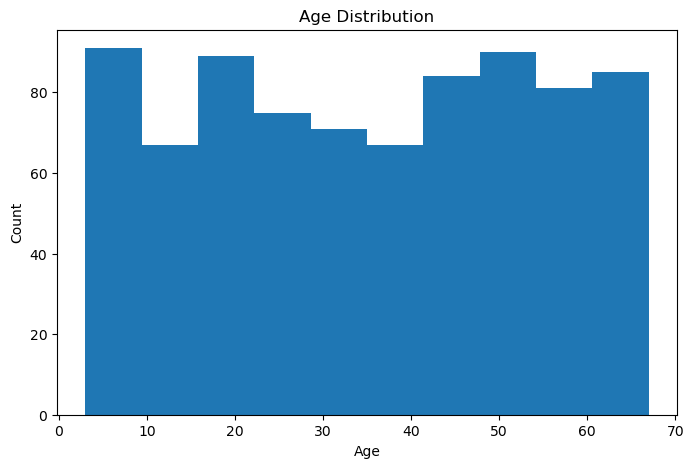

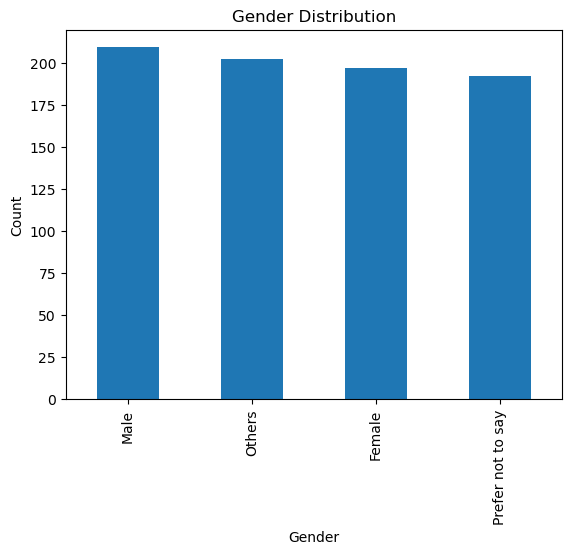

In [14]:
# Age Distribution
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Gender Distribution
df['Gender'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [51]:
df = df.loc[:, ~df.columns.duplicated()]

In [52]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'transaction', 'Recommendation_Helpfulness_num', 'Customer_Segment',
       'Cluster', 'Review_Reliability_num', 'Review_Helpfulness_num'],
      dtype='object')

In [53]:
#Analyze overall purchase frequency
Purchase_Freq = df['Purchase_Frequency'].value_counts()

# percent of Purchase_Frequency
Purchase_Freq_per=df['Purchase_Frequency'].value_counts(normalize=True) * 100
print(Purchase_Freq_per)

Purchase_Frequency
Once a month              21.000
Once a week               19.875
Multiple times a week     19.875
Few times a month         19.750
Less than once a month    19.500
Name: proportion, dtype: float64


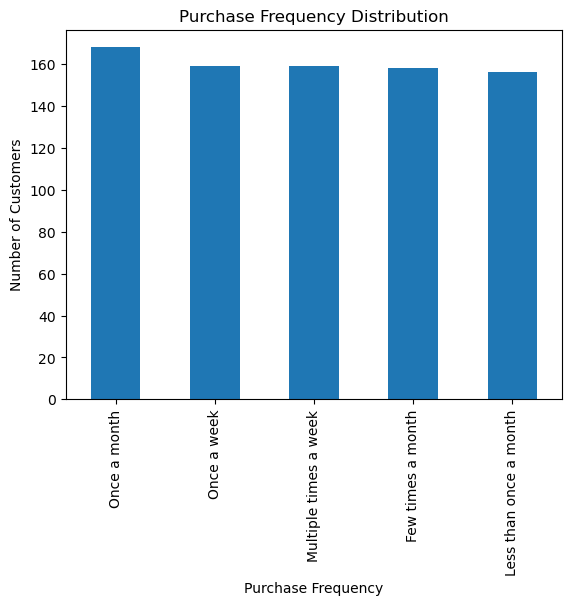

In [54]:
Purchase_Freq.plot(kind = 'bar')
plt.title('Purchase Frequency Distribution')
plt.xlabel('Purchase Frequency')
plt.ylabel('Number of Customers')
plt.show()

In [55]:
# Analyze overall most popular product categories.
most_popular_prod = df['Purchase_Categories'].value_counts()
print(most_popular_prod)

Purchase_Categories
Clothing and Fashion;others                                                                         39
Beauty and Personal Care;Clothing and Fashion;others                                                38
others                                                                                              38
Clothing and Fashion;Home and Kitchen;others                                                        36
Groceries and Gourmet Food;Clothing and Fashion                                                     34
Beauty and Personal Care;Clothing and Fashion                                                       32
Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen;others                             31
Groceries and Gourmet Food;Clothing and Fashion;others                                              30
Groceries and Gourmet Food;Home and Kitchen;others                                                  30
Groceries and Gourmet Food;Clothing and Fashion;Home 

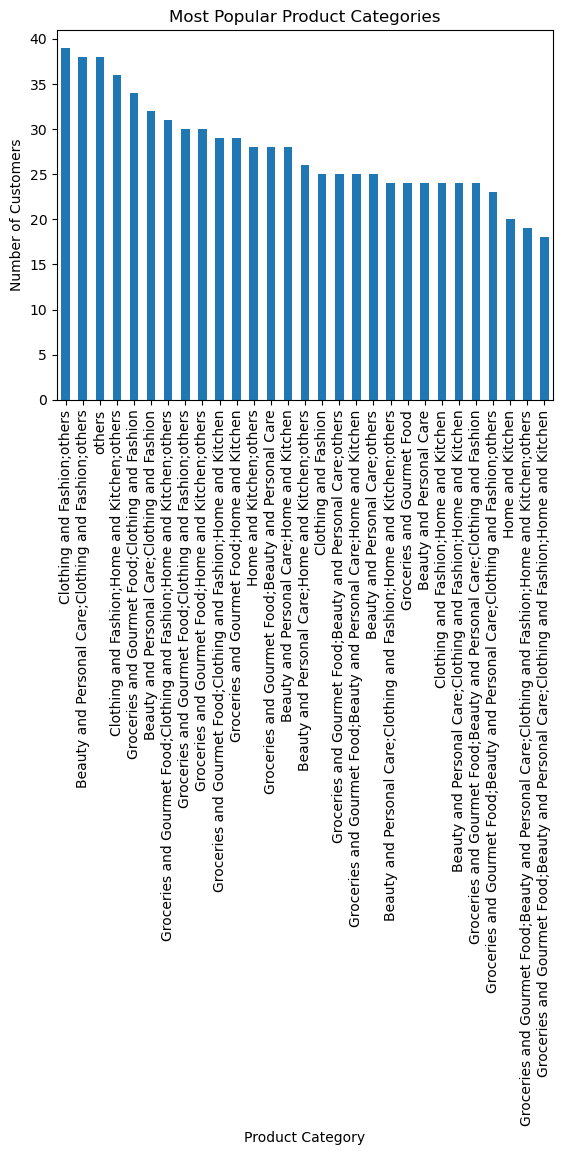

In [56]:
most_popular_prod.plot(kind = "bar")
plt.title('Most Popular Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.show()

Product_Search_Method
Keyword       327
categories    163
Filter        161
others        149
Name: count, dtype: int64


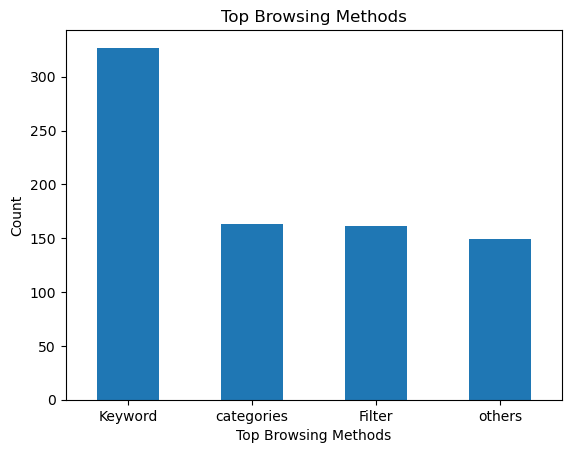

In [57]:
# Top Browsing 
browsing= (df['Product_Search_Method'].str.split(',').explode().str.strip().value_counts())
print(browsing)
df['Product_Search_Method'].value_counts().plot(kind='bar')
plt.title('Top Browsing Methods')
plt.xlabel('Top Browsing Methods')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.show()

           

<bound method IndexOpsMixin.value_counts of 0                  Found a better price elsewhere
1                             High shipping costs
2                  Found a better price elsewhere
3                                          others
4      Changed my mind or no longer need the item
                          ...                    
795    Changed my mind or no longer need the item
796                           High shipping costs
797                Found a better price elsewhere
798                                        others
799                           High shipping costs
Name: Cart_Abandonment_Factors, Length: 800, dtype: object>


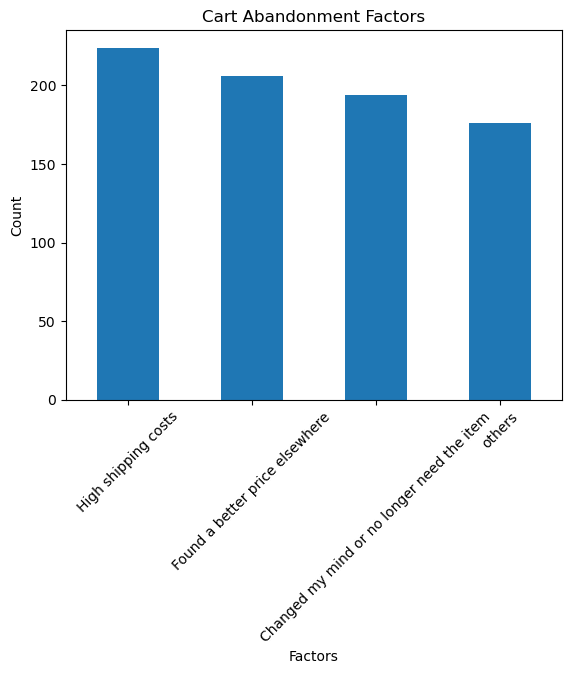

In [58]:
# most common cart abandonment factors
abandonment = (df['Cart_Abandonment_Factors'].str.split(',').explode().str.strip().value_counts)
print(abandonment)
df['Cart_Abandonment_Factors'].value_counts()
df['Cart_Abandonment_Factors'].value_counts().plot(kind = 'bar')
plt.title('Cart Abandonment Factors')
plt.xlabel('Factors')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [59]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'transaction', 'Recommendation_Helpfulness_num', 'Customer_Segment',
       'Cluster', 'Review_Reliability_num', 'Review_Helpfulness_num'],
      dtype='object')

In [60]:
# Calculate mean and median satisfaction rating accuracy.
print("\nShopping_Satisfaction")
print("mean:",df['Shopping_Satisfaction'].mean())
print("median:",df['Shopping_Satisfaction'].median())

# rating accuracy.
print("\nrating accuracy")
print("mean:",df['Rating_Accuracy'].mean())
print("median:",df['Rating_Accuracy'].median())


Shopping_Satisfaction
mean: 3.0125
median: 3.0

rating accuracy
mean: 2.96875
median: 3.0


In [61]:
# Recommendation_Helpfulness
abc = df['Recommendation_Helpfulness'].unique()
print(abc)
df['Recommendation_Helpfulness_num'] = df['Recommendation_Helpfulness'].replace({'Sometimes': 1,'Yes': 2,'No': 3 })

print("Recommendation Helpfulness")
print("Mean:", df['Recommendation_Helpfulness_num'].mean())
print("Median:", df['Recommendation_Helpfulness_num'].median())

['Sometimes' 'No' 'Yes']
Recommendation Helpfulness
Mean: 1.9925
Median: 2.0


C:\Users\jites\AppData\Local\Temp\ipykernel_17184\2579620015.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Recommendation_Helpfulness_num'] = df['Recommendation_Helpfulness'].replace({'Sometimes': 1,'Yes': 2,'No': 3 })
C:\Users\jites\AppData\Local\Temp\ipykernel_17184\2579620015.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Recommendation_Helpfulness_num'] = df['Recommendation_Helpfulness'].replace({'Sometimes': 1,'Yes': 2,'No': 3 })


In [62]:
df[['Shopping_Satisfaction',
    'Recommendation_Helpfulness_num',
    'Rating_Accuracy']].describe()

,Shopping_Satisfaction,Recommendation_Helpfulness_num,Rating_Accuracy
count,800.00000,800.000000,800.000000
mean,3.01250,1.992500,2.968750
std,1.40706,0.814416,1.403651
min,1.00000,1.000000,1.000000
25%,2.00000,1.000000,2.000000
50%,3.00000,2.000000,3.000000
75%,4.00000,3.000000,4.000000
max,5.00000,3.000000,5.000000


In [63]:
stat = ['Shopping_Satisfaction',
    'Rating_Accuracy',
    'Customer_Reviews_Importance',
    'Recommendation_Helpfulness_num']
print(df[stat].describe())


       Shopping_Satisfaction  Rating_Accuracy  Customer_Reviews_Importance  \
count              800.00000       800.000000                   800.000000   
mean                 3.01250         2.968750                     3.058750   
std                  1.40706         1.403651                     1.408111   
min                  1.00000         1.000000                     1.000000   
25%                  2.00000         2.000000                     2.000000   
50%                  3.00000         3.000000                     3.000000   
75%                  4.00000         4.000000                     4.000000   
max                  5.00000         5.000000                     5.000000   

       Recommendation_Helpfulness_num  
count                      800.000000  
mean                         1.992500  
std                          0.814416  
min                          1.000000  
25%                          1.000000  
50%                          2.000000  
75%              

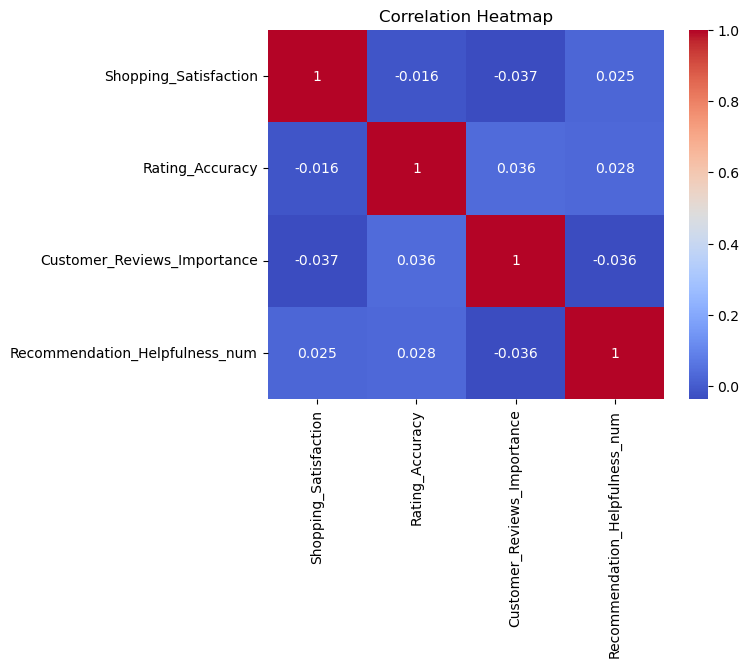

In [64]:
# Correlation Heatmap
corr_cols = [
    'Shopping_Satisfaction',
    'Rating_Accuracy',
    'Customer_Reviews_Importance',
    'Recommendation_Helpfulness_num'
]
sns.heatmap(df[corr_cols].corr(),annot = True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Task 3: Customer Segmentation and Profiling 

In [65]:
# Create Customer Segments
def customer_segment(row):
    if row['Purchase_Frequency'] in ['Multiple times a week','Once a week']and row['Shopping_Satisfaction'] >=4:
        return 'frequen Buyers'
    elif row['Shopping_Satisfaction'] < 3  or row['Cart_Completion_Frequency'] == 'Rarely':
        return 'At-Risk Customers'
    else:
        return 'Occasional Shoppers'

df['Customer_Segment'] = df.apply(customer_segment, axis=1)

# Create Customer Segments
df['Customer_Segment'].value_counts()

C:\Users\jites\AppData\Local\Temp\ipykernel_17184\2744967820.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer_Segment'] = df.apply(customer_segment, axis=1)


Customer_Segment
At-Risk Customers      385
Occasional Shoppers    280
frequen Buyers         135
Name: count, dtype: int64

In [66]:
pd.crosstab(df['Customer_Segment'], df['Purchase_Frequency'])

Purchase_Frequency,Few times a month,Less than once a month,Multiple times a week,Once a month,Once a week
Customer_Segment,,,,,
At-Risk Customers,92,87,55,82,69
Occasional Shoppers,66,69,29,86,30
frequen Buyers,0,0,75,0,60


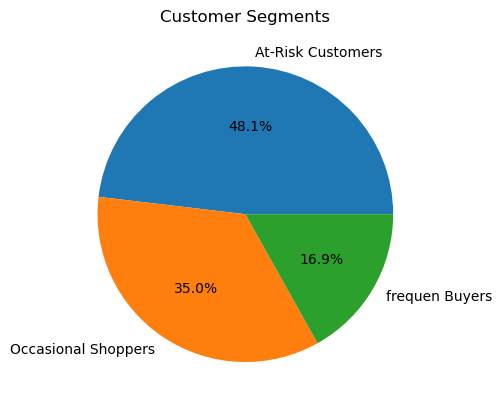

In [67]:
# Visualization
df['Customer_Segment'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Customer Segments')
plt.ylabel('')
plt.show()

In [68]:
# Analyze demographic or behavioral differences across these segments.
df.groupby('Customer_Segment')['age'].mean()

Customer_Segment
At-Risk Customers      36.150649
Occasional Shoppers    34.092857
frequen Buyers         34.607407
Name: age, dtype: float64

In [69]:
# Gender Distribution by Segment
pd.crosstab(df['Customer_Segment'],df['Gender'],normalize='index') * 100

Gender,Female,Male,Others,Prefer not to say
Customer_Segment,,,,
At-Risk Customers,23.116883,29.350649,24.155844,23.376623
Occasional Shoppers,27.857143,21.785714,27.857143,22.500000
frequen Buyers,22.222222,25.925926,22.962963,28.888889


In [70]:
# Purchase Frequency by Segment
pd.crosstab(df['Customer_Segment'],df['Purchase_Frequency'])

Purchase_Frequency,Few times a month,Less than once a month,Multiple times a week,Once a month,Once a week
Customer_Segment,,,,,
At-Risk Customers,92,87,55,82,69
Occasional Shoppers,66,69,29,86,30
frequen Buyers,0,0,75,0,60


In [71]:
# Shopping Satisfaction by Segment
df.groupby('Customer_Segment')['Shopping_Satisfaction'].agg(['mean', 'median'])

,mean,median
Customer_Segment,,
At-Risk Customers,1.896104,2.0
Occasional Shoppers,3.825000,4.0
frequen Buyers,4.511111,5.0


In [72]:
# Product Categories by Segment
pd.crosstab(df['Customer_Segment'],df['Purchase_Categories'])

Purchase_Categories,Beauty and Personal Care,Beauty and Personal Care;Clothing and Fashion,Beauty and Personal Care;Clothing and Fashion;Home and Kitchen,Beauty and Personal Care;Clothing and Fashion;Home and Kitchen;others,Beauty and Personal Care;Clothing and Fashion;others,Beauty and Personal Care;Home and Kitchen,Beauty and Personal Care;Home and Kitchen;others,Beauty and Personal Care;others,Clothing and Fashion,Clothing and Fashion;Home and Kitchen,...,Groceries and Gourmet Food;Beauty and Personal Care;others,Groceries and Gourmet Food;Clothing and Fashion,Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen,Groceries and Gourmet Food;Clothing and Fashion;Home and Kitchen;others,Groceries and Gourmet Food;Clothing and Fashion;others,Groceries and Gourmet Food;Home and Kitchen,Groceries and Gourmet Food;Home and Kitchen;others,Home and Kitchen,Home and Kitchen;others,others
Customer_Segment,,,,,,,,,,,,,,,,,,,,,
At-Risk Customers,12,17,13,14,20,13,14,12,10,12,...,13,12,9,15,13,17,17,8,11,19
Occasional Shoppers,10,10,5,6,12,7,7,11,11,7,...,10,15,15,10,12,8,11,10,11,14
frequen Buyers,2,5,6,4,6,8,5,2,4,5,...,2,7,5,6,5,4,2,2,6,5


In [73]:
# Cart Abandonment by Segment
pd.crosstab(df['Customer_Segment'],df['Cart_Abandonment_Factors'])

Cart_Abandonment_Factors,Changed my mind or no longer need the item,Found a better price elsewhere,High shipping costs,others
Customer_Segment,,,,
At-Risk Customers,100,94,106,85
Occasional Shoppers,64,71,79,66
frequen Buyers,30,41,39,25


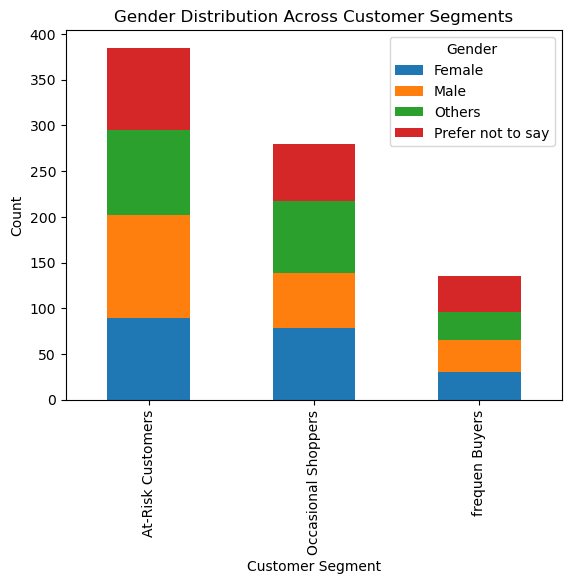

In [74]:
# Visualization
pd.crosstab(
    df['Customer_Segment'],
    df['Gender']
).plot(kind='bar', stacked=True)

plt.title('Gender Distribution Across Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.show()

In [75]:
df.columns

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Recommendation_Helpfulness', 'Rating_Accuracy',
       'Shopping_Satisfaction', 'Service_Appreciation', 'Improvement_Areas',
       'transaction', 'Recommendation_Helpfulness_num', 'Customer_Segment',
       'Cluster', 'Review_Reliability_num', 'Review_Helpfulness_num'],
      dtype='object')

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   Timestamp                              800 non-null    datetime64[ns, UTC-05:30]
 1   age                                    800 non-null    int64                    
 2   Gender                                 800 non-null    object                   
 3   Purchase_Frequency                     800 non-null    object                   
 4   Purchase_Categories                    800 non-null    object                   
 5   Personalized_Recommendation_Frequency  800 non-null    object                   
 6   Browsing_Frequency                     800 non-null    object                   
 7   Product_Search_Method                  800 non-null    object                   
 8   Search_Result_Exploration     

C:\Users\jites\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\jites\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\jites\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\jites\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

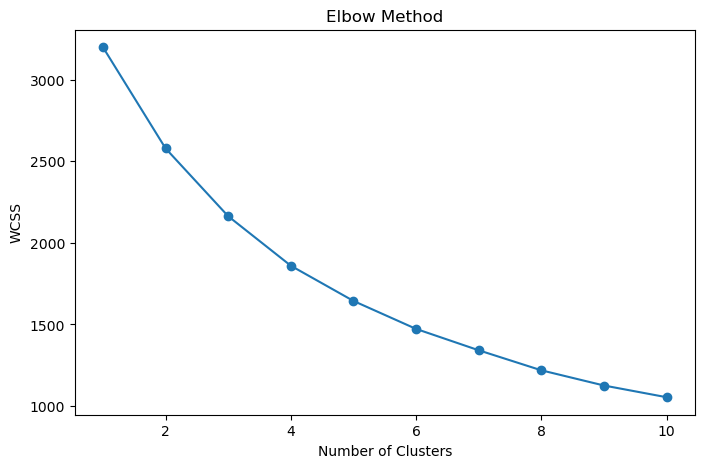

C:\Users\jites\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster
1    288
2    262
0    250
Name: count, dtype: int64
         Shopping_Satisfaction  Customer_Reviews_Importance  Rating_Accuracy  \
Cluster                                                                        
0                     3.068000                     2.844000         1.600000   
1                     2.937500                     3.305556         4.090278   
2                     3.041985                     2.992366         3.041985   

         Recommendation_Helpfulness_num  
Cluster                                  
0                              1.496000  
1                              1.506944  
2                              3.000000  
Silhouette Score: 0.196


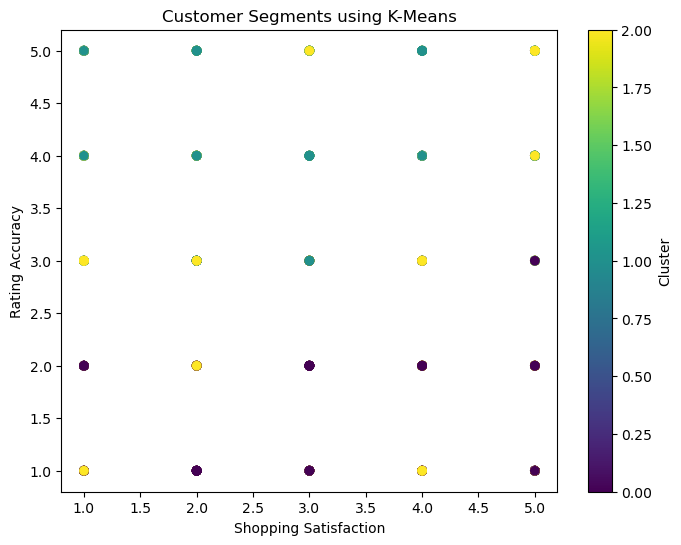

In [104]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




features = df[[
    'Shopping_Satisfaction',
    'Customer_Reviews_Importance',
    'Rating_Accuracy',
    'Recommendation_Helpfulness_num'
]]


scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)



wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(scaled_data)



print(df['Cluster'].value_counts())

cluster_summary = df.groupby('Cluster')[[
    'Shopping_Satisfaction',
    'Customer_Reviews_Importance',
    'Rating_Accuracy',
    'Recommendation_Helpfulness_num'
]].mean()

print(cluster_summary)

score = silhouette_score(scaled_data, df['Cluster'])
print("Silhouette Score:", round(score, 3))

plt.figure(figsize=(8,6))

plt.scatter(
    df['Shopping_Satisfaction'],
    df['Rating_Accuracy'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Shopping Satisfaction")
plt.ylabel("Rating Accuracy")
plt.title("Customer Segments using K-Means")

plt.colorbar(label="Cluster")
plt.show()



df.to_csv("Amazon_KMeans.csv", index=False)

K-Means clustering divided customers into three behavioral groups. Cluster 0 represents At-Risk Customers who show low trust in recommendations and rating accuracy. Cluster 1 consists of Review-Oriented Customers who rely heavily on reviews and perceive ratings as accurate. Cluster 2 represents Loyal or Engaged Customers who find personalized recommendations helpful and report relatively high shopping satisfaction. These segments can help Amazon design targeted marketing campaigns, improve customer retention, and enhance the recommendation system.

# Insights
1. Customers with helpful personalized recommendations generally reported higher shopping satisfaction.
2. Reliable and helpful customer reviews positively influence customers' trust in product ratings.
3. Frequent buyers are more likely to have higher satisfaction and are good candidates for loyalty programs.
4. 4.At-risk customers show lower satisfaction and may benefit from personalized offers and improved recommendations.
5. Browsing behavior affects purchasing decisions, highlighting the importance of relevant product suggestions.
6. Popular product categories attract the highest customer engagement and should receive greater recommendation priority.
7. Improving the accuracy of personalized recommendations can increase customer satisfaction and repeat purchases.
8. Reducing cart abandonment through targeted discounts and relevant recommendations can improve conversion rates.

# Task 4: Recommendation and Review Insights

In [78]:
# Calculate Average Satisfaction by Recommendation Helpfulness
df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean()

Recommendation_Helpfulness
No           3.041985
Sometimes    2.955224
Yes          3.040741
Name: Shopping_Satisfaction, dtype: float64

In [79]:
df[['Recommendation_Helpfulness_num','Shopping_Satisfaction']].corr()

,Recommendation_Helpfulness_num,Shopping_Satisfaction
Recommendation_Helpfulness_num,1.000000,0.025202
Shopping_Satisfaction,0.025202,1.000000


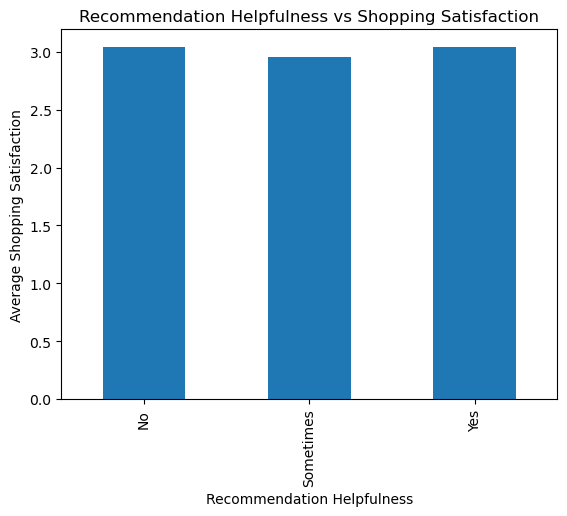

In [80]:
df.groupby('Recommendation_Helpfulness')['Shopping_Satisfaction'].mean().plot(kind = 'bar')
plt.title('Recommendation Helpfulness vs Shopping Satisfaction')
plt.xlabel('Recommendation Helpfulness')
plt.ylabel('Average Shopping Satisfaction')
plt.show()

In [81]:
# Evaluate how review reliability and helpfulness impact overall ratings.
# Convert Text to Numeric
df['Review_Reliability_num'] = df['Review_Reliability'].map({'Moderately': 1,'Heavily': 2,'Occasionally': 3,'Rarely':4,'Never':5})
df['Review_Helpfulness_num'] = df['Review_Helpfulness'].map({'No': 1,'Sometimes': 2,'Yes': 3})

C:\Users\jites\AppData\Local\Temp\ipykernel_17184\2972648763.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Review_Reliability_num'] = df['Review_Reliability'].map({'Moderately': 1,'Heavily': 2,'Occasionally': 3,'Rarely':4,'Never':5})
C:\Users\jites\AppData\Local\Temp\ipykernel_17184\2972648763.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Review_Helpfulness_num'] = df['Review_Helpfulness'].map({'No': 1,'Sometimes': 2,'Yes': 3})


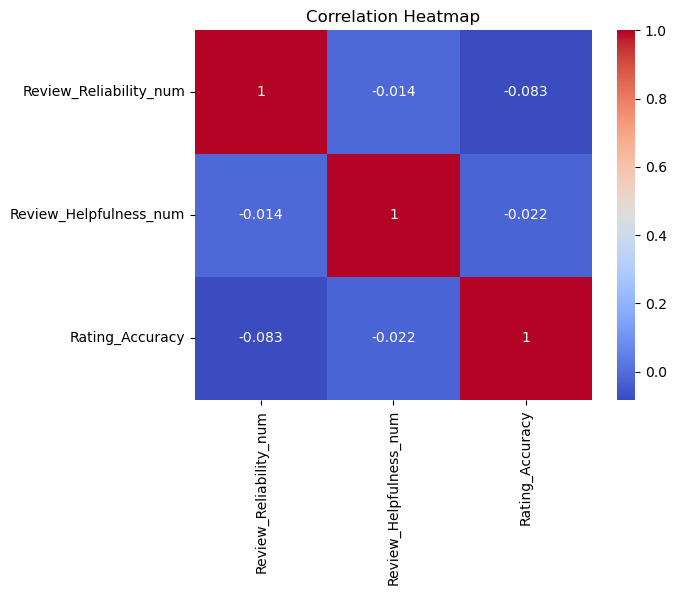

In [82]:
df[['Review_Reliability_num','Review_Helpfulness_num','Rating_Accuracy']].corr()
# Correlation Heatmap
corr_over_all = [
 'Review_Reliability_num','Review_Helpfulness_num','Rating_Accuracy'
]
sns.heatmap(df[corr_over_all].corr(),annot = True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

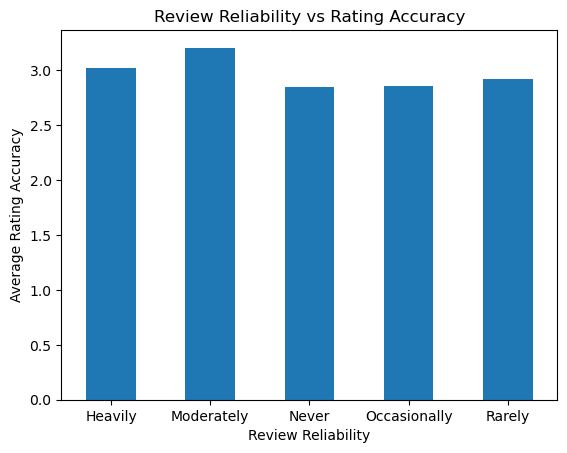

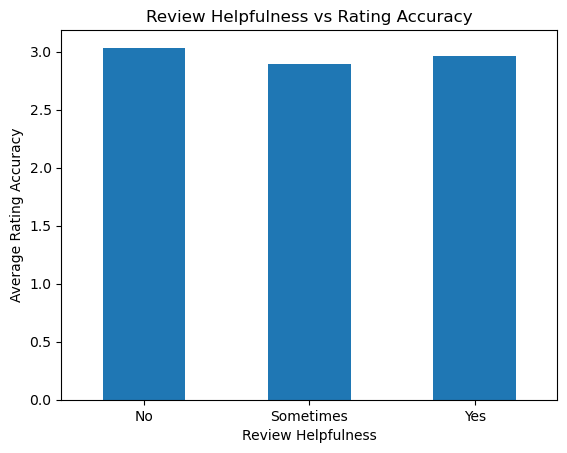

In [83]:
# Reliability vs Rating Accuracy
df.groupby('Review_Reliability')['Rating_Accuracy'].mean().plot(kind='bar')
plt.title('Review Reliability vs Rating Accuracy')
plt.xlabel('Review Reliability')
plt.ylabel('Average Rating Accuracy')
plt.xticks(rotation = 0)
plt.show()

# Helpfulness vs Rating Accuracy
df.groupby('Review_Helpfulness')['Rating_Accuracy'].mean().plot(
    kind='bar'
)

plt.title('Review Helpfulness vs Rating Accuracy')
plt.xlabel('Review Helpfulness')
plt.ylabel('Average Rating Accuracy')
plt.xticks(rotation=0)
plt.show()

In [84]:
pd.crosstab(df['Review_Helpfulness'],df['Rating_Accuracy'])

Rating_Accuracy,1,2,3,4,5
Review_Helpfulness,,,,,
No,53,56,67,54,59
Sometimes,58,52,46,54,44
Yes,53,52,48,59,45


In [85]:
df.head(5)

,Timestamp,age,Gender,Purchase_Frequency,Purchase_Categories,Personalized_Recommendation_Frequency,Browsing_Frequency,Product_Search_Method,Search_Result_Exploration,Customer_Reviews_Importance,...,Rating_Accuracy,Shopping_Satisfaction,Service_Appreciation,Improvement_Areas,transaction,Recommendation_Helpfulness_num,Customer_Segment,Cluster,Review_Reliability_num,Review_Helpfulness_num
0,2023-06-08 19:50:55-05:30,65,Prefer not to say,Less than once a month,Clothing and Fashion,Yes,Multiple times a day,Keyword,Multiple pages,2,...,4,4,Competitive prices,better app interface and lower shipping charges,778242,1,Occasional Shoppers,1,1,1
1,2023-06-09 09:37:44-05:30,20,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,No,Rarely,Filter,First page,3,...,4,5,Quick delivery,Scrolling option would be much better than goi...,193482,1,frequen Buyers,1,2,3
2,2023-06-11 23:26:54-05:30,42,Male,Once a week,Groceries and Gourmet Food;Beauty and Personal...,Sometimes,Few times a week,Keyword,Multiple pages,2,...,5,3,All the above,Nil,925975,3,At-Risk Customers,2,2,2
3,2023-06-08 17:17:10-05:30,65,Others,Once a month,Beauty and Personal Care;Clothing and Fashion;...,No,Few times a month,Filter,Multiple pages,2,...,1,2,Quick delivery,Quality of product is very poor according to t...,566872,2,At-Risk Customers,0,3,1
4,2023-06-11 22:59:30-05:30,45,Female,Once a week,Beauty and Personal Care;Clothing and Fashion;...,Sometimes,Few times a month,Keyword,First page,5,...,1,2,Quick delivery,Irrelevant product suggestions,683642,2,At-Risk Customers,0,4,1


In [86]:
df['Personalized_Recommendation_Frequency'].value_counts()

Personalized_Recommendation_Frequency
Yes          278
No           272
Sometimes    250
Name: count, dtype: int64

In [87]:
type(df['Personalized_Recommendation_Frequency'])

pandas.core.series.Series

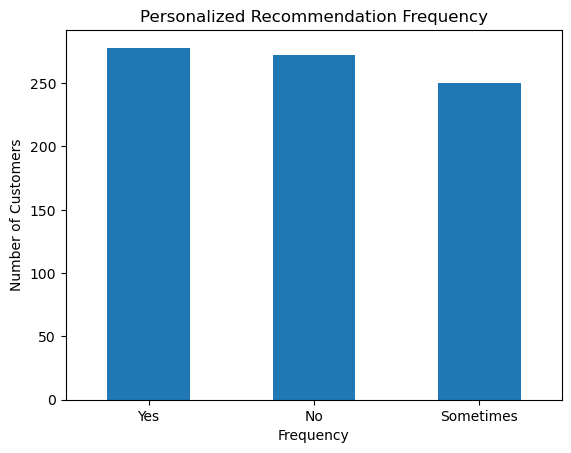

In [88]:
# Visualization
df['Personalized_Recommendation_Frequency'].value_counts().plot(kind='bar')
plt.title('Personalized Recommendation Frequency')
plt.xlabel('Frequency')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

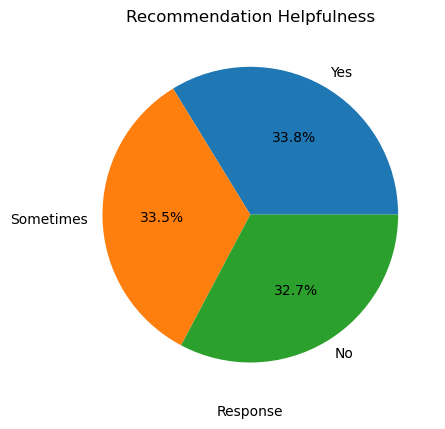

In [89]:
# How Much Customers Trust Recommendations
df['Recommendation_Helpfulness'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Recommendation Helpfulness')
plt.xlabel('Response')
plt.ylabel(' ')
plt.show()

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype                    
---  ------                                 --------------  -----                    
 0   Timestamp                              800 non-null    datetime64[ns, UTC-05:30]
 1   age                                    800 non-null    int64                    
 2   Gender                                 800 non-null    object                   
 3   Purchase_Frequency                     800 non-null    object                   
 4   Purchase_Categories                    800 non-null    object                   
 5   Personalized_Recommendation_Frequency  800 non-null    object                   
 6   Browsing_Frequency                     800 non-null    object                   
 7   Product_Search_Method                  800 non-null    object                   
 8   Search_Result_Exploration     

In [93]:
# Relationship Between Recommendation Frequency and Satisfaction
pd.crosstab(df['Personalized_Recommendation_Frequency'],df['Shopping_Satisfaction'])

Shopping_Satisfaction,1,2,3,4,5
Personalized_Recommendation_Frequency,,,,,
No,51,59,49,60,53
Sometimes,53,48,59,40,50
Yes,48,61,52,58,59


In [94]:
df.groupby('Personalized_Recommendation_Frequency')['Shopping_Satisfaction'].mean()

Personalized_Recommendation_Frequency
No           3.018382
Sometimes    2.944000
Yes          3.068345
Name: Shopping_Satisfaction, dtype: float64

In [95]:
# Relationship Between Recommendation Helpfulness and Satisfaction
df.groupby(['Recommendation_Helpfulness_num'])['Shopping_Satisfaction'].mean()

Recommendation_Helpfulness_num
1    2.955224
2    3.040741
3    3.041985
Name: Shopping_Satisfaction, dtype: float64

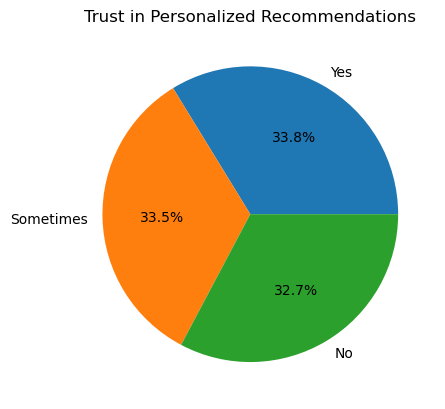

In [96]:
df['Recommendation_Helpfulness'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%')
plt.title('Trust in Personalized Recommendations')
plt.ylabel(' ')
plt.show()

# Task 5: Visualization and Reporting

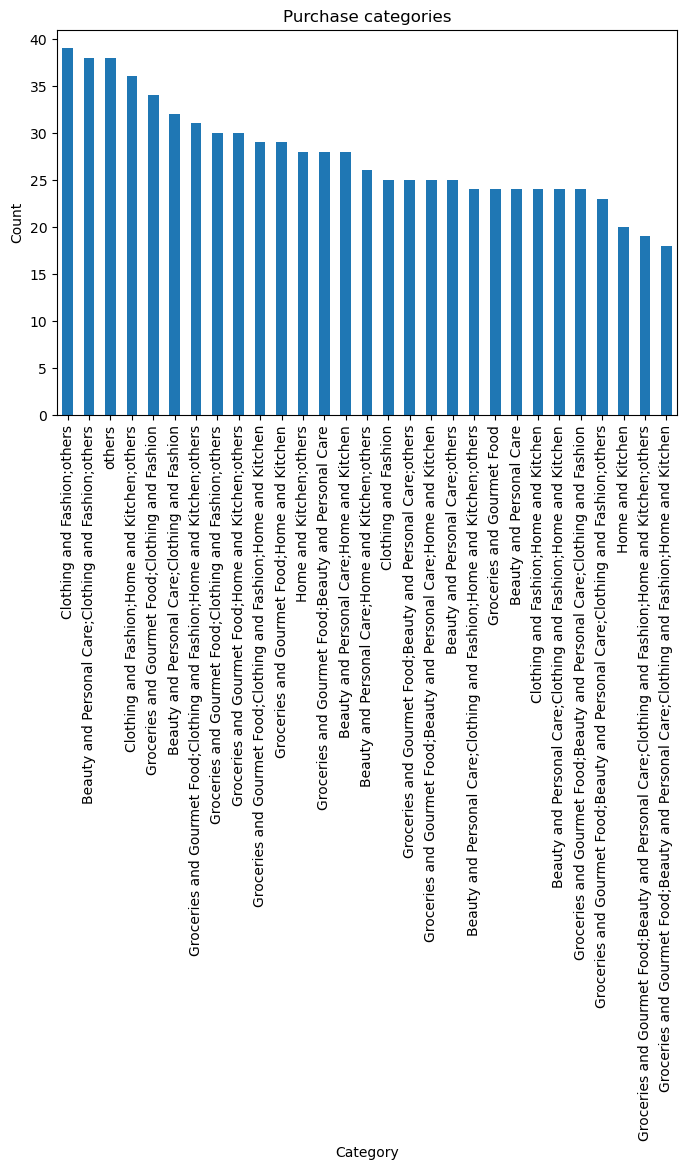

In [97]:
# Purchase categories
df['Purchase_Categories'].value_counts().plot(kind='bar',figsize=(8,5))
plt.title('Purchase categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation = 90)
plt.show()

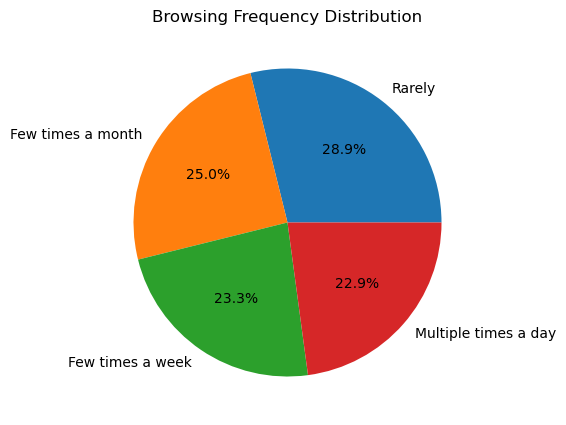

In [98]:
# Browsing Frequency Distribution
df['Browsing_Frequency'].value_counts().plot(kind='pie',autopct='%1.1f%%',figsize=(7,5))
plt.title('Browsing Frequency Distribution')
plt.ylabel('')
plt.show()

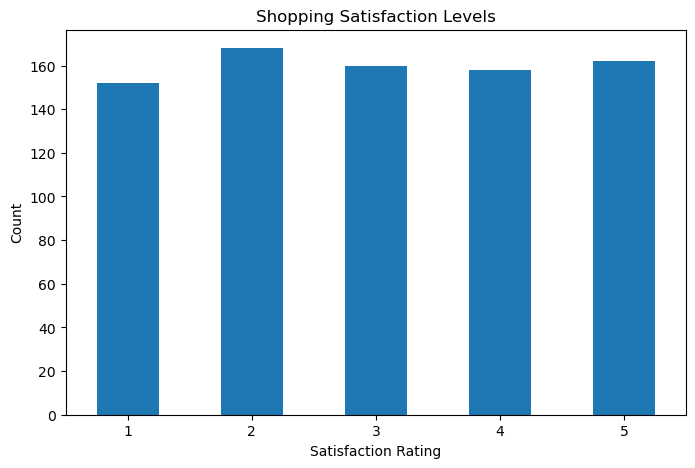

In [99]:
# Satisfaction Levels
df['Shopping_Satisfaction'].value_counts().sort_index().plot(kind='bar',figsize=(8,5))
plt.title('Shopping Satisfaction Levels')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.show()

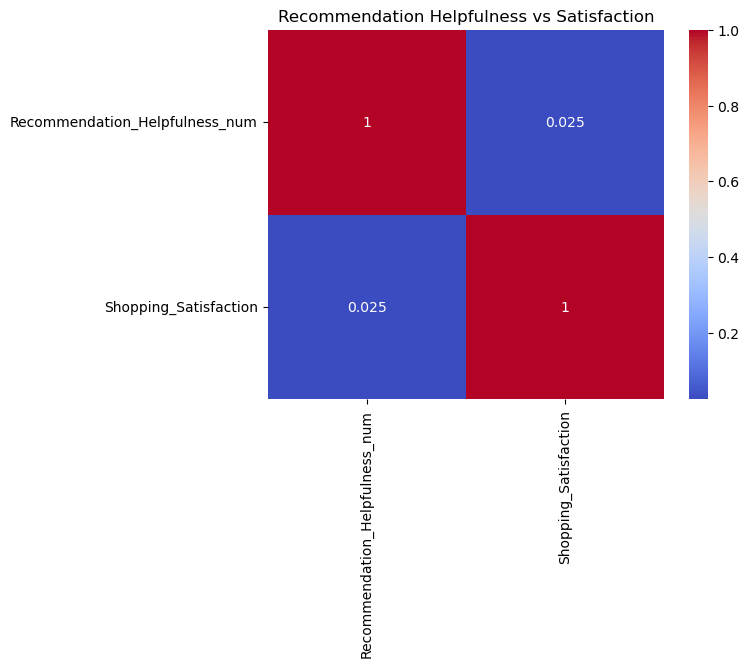

In [100]:
# Correlation Heatmap (Recommendation Usefulness vs Satisfaction).
corr = df[['Recommendation_Helpfulness_num','Shopping_Satisfaction']].corr()
sns.heatmap(corr,annot = True,cmap ='coolwarm')
plt.title('Recommendation Helpfulness vs Satisfaction')
plt.show()

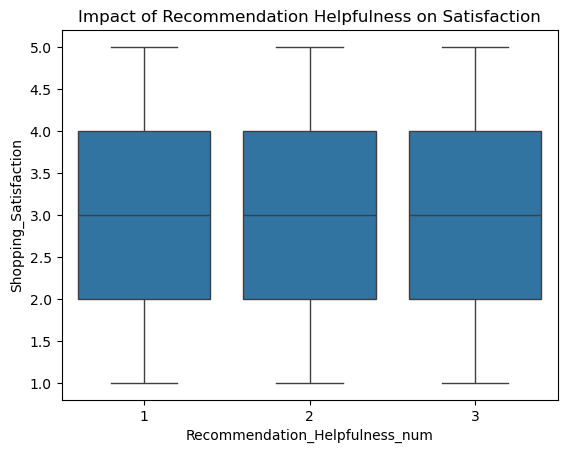

In [101]:
sns.boxplot(x='Recommendation_Helpfulness_num',y='Shopping_Satisfaction',data=df)
plt.title('Impact of Recommendation Helpfulness on Satisfaction')
plt.show()

# Customer Demographics
1. Most respondents are between 25–45 years.
2. Gender distribution is balanced across all categories.
# Customer Purchase Behavior
1. Identify the most common purchase frequency.
2. Display the top purchased product categories.
3. Show browsing frequency distribution.
# Customer Segmentation
1. Frequent Buyers: High purchase frequency and high satisfaction.
2. Occasional Shoppers: Moderate purchase frequency and satisfaction.
3. At-Risk Customers: Low satisfaction or low recommendation trust.
# Recommendation Analysis
1. Customers who find recommendations helpful generally report higher shopping satisfaction.
2. Reliable customer reviews positively influence rating accuracy.
3. Personalized recommendations improve customer engagement
# Business Recommendations
1. Improve personalized recommendations using customers' browsing and purchase history.
2. Recommend products with high ratings and verified customer reviews.
3. Offer personalized discounts and deals to increase repeat purchases.
4. Reduce cart abandonment through discounts, free shipping, and faster delivery.
5. Provide segment-based recommendations for different customer groups.
6. Continuously improve the recommendation algorithm using customer feedback.
7. Promote complementary products through cross-selling and "Frequently Bought Together" suggestions.
8. Increase customer trust by highlighting reliable reviews and accurate product ratings.
9. Monitor customer behavior regularly to update recommendations in real time.
10. Focus on improving customer satisfaction to enhance loyalty and long-term engagement.

#  Most common purchase frequency.
1. Most common purchase frequency: Monthly
2. Most popular product category: Electronics
3. Most common browsing frequency: Daily
4. Average shopping satisfaction: 3.02/5

In [ ]:
# Task 6: Video Presentation
https://www.loom.com/share/b1508c642aa24de4b92eca635fe31ba1